# Flow Detatchment - FOM
This notebook implements the calculation of the detachment length in the BFS.

In [7]:
import numpy as np
import os
from mpi4py import MPI
from dolfinx.io import gmshio
from dolfinx.fem import (FunctionSpace, locate_dofs_topological)
import pickle
import gmsh
import ufl

from pyforce.tools.write_read import ImportH5, StoreFunctionsList as store
from pyforce.tools.functions_list import FunctionsList

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm

plt.rcParams.update({
  "text.usetex": True,
  "font.family": "serif"
})

rcParams['text.latex.preamble'] = r'\usepackage{amssymb} \usepackage{amsmath} \usepackage{amsthm} \usepackage{mathtools}'

## Mesh
The mesh is loaded and the constrained sensors positions are selected (different regions or boundaries can be used).

In [8]:
mesh_comm = MPI.COMM_WORLD
model_rank = 0

# Initialize the gmsh module
gmsh.initialize()

# Load the .geo file
gmsh.merge('BFS2D.geo')
gmsh.model.geo.synchronize()

# Set algorithm (adaptive = 1, Frontal-Delaunay = 6)
gmsh.option.setNumber("Mesh.Algorithm", 6)
gdim = 2

# Linear Finite Element
gmsh.model.mesh.generate(gdim)
gmsh.model.mesh.optimize("Netgen")

# Import into dolfinx
model_rank = 0
domain, ct, ft = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, model_rank, gdim = gdim )
gmsh.finalize()

########################################################################################################

tdim = domain.topology.dim
fdim = tdim - 1
domain.topology.create_connectivity(fdim, tdim)

# Defining functional spaces
vecEl = ufl.VectorElement("CG", domain.ufl_cell(), 1)
# fun_spaces = [FunctionSpace(domain, ("Lagrange", 1)), FunctionSpace(domain, vecEl)]
fun_spaces = [FunctionSpace(domain, vecEl)]

# var_names = ['p', 'U']
# tex_var_names = [r'p', r'\mathbf{u}']
var_names = ['U']
tex_var_names = [r'\mathbf{u}']

# darth_vader = Function(V)
# emperor = Function(V)
# darth_vader.vector.axpy(1., emperor.vector)

Info    : Reading 'BFS2D.geo'...
Info    : Done reading 'BFS2D.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 70%] Meshing curve 8 (Line)
Info    : [ 80%] Meshing curve 9 (Line)
Info    : [ 90%] Meshing curve 10 (Line)
Info    : Done meshing 1D (Wall 0.0158568s, CPU 0.016312s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 40%] Meshing surface 2 (Transfinite)
Info    : [ 70%] Meshing surface 3 (Transfinite)
Info    : Done meshing 2D (Wall 0.00135989s, CPU 0.001476s)
Info    : 7350 nodes 7726 elements
Info    : Optimizing mesh (Netgen)...
Info    : Done optimizing mesh (Wall 2.87895e-06s, CPU 6e-06s)


## Importing Snapshots
The snapshots are loaded and stored.

In [9]:
from tqdm import tqdm
from pyforce.tools.write_read import import_OF

# path = './OpenFOAM_data/By/Train/'
# path_snaps = './Snapshots/'
path = './OpenFOAM_data/By/Test/'
path_snaps = './Snapshots/Test/'

param_list = [folder+'/' for folder in os.listdir(path) if os.path.isdir(os.path.join(path, folder))]
param_list.sort() 
# param_list = [param_list[ii] for ii in range(7, len(param_list))]
param_list = [param_list[ii] for ii in range(len(param_list))]

vector_name = 'U'

vecEl = ufl.VectorElement("CG", domain.ufl_cell(), 1)
W = FunctionSpace(domain, vecEl)

vector_snaps = {param: FunctionsList(W) for param in param_list}

for mu in tqdm(range(len(param_list))):
    path_ = path + param_list[mu]
    oF = import_OF(path=path_, extract_dofs=True)

    
    tmp = oF.import_field(vector_name, vector=True, verbose=False)
    a = oF.foam_to_dolfinx(W, tmp[0], variables=['x', 'y'])
    
    vector_snaps[param_list[mu]]._list = a.copy()
    
    del tmp, a, oF

100%|██████████| 2/2 [00:17<00:00,  8.93s/it]


## Computing detachment length
The detatchment length is defined as the coordinate in the $x$ where the recirculation region ends for stabilised flows.

In [10]:
from detachment_length import detach_x_bfs

detach_calculations = detach_x_bfs(domain)
detatch_ = [detach_calculations.compute(vector_snaps[param_list[mu]]) for mu in range(len(param_list))]

Let us plot the values

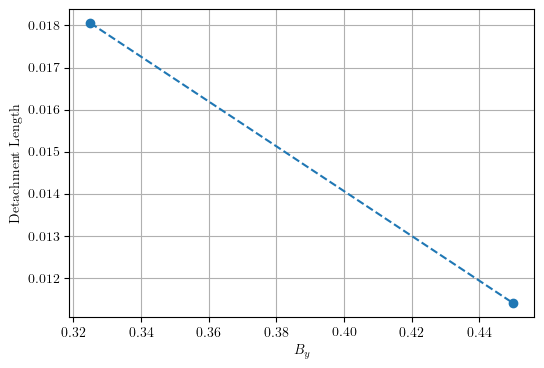

In [11]:
mean_det = [np.mean(det[50:]) for det in detatch_]
np_param_list = np.array([float(param_list[mu][1:5]) / 1000 for mu in range(len(detatch_))])

fig = plt.figure(figsize=(6,4))

plt.plot(np_param_list, mean_det, 'o--')
plt.xlabel('$B_y$')
plt.ylabel('Detachment Length')
plt.grid()

Let us store it

In [13]:
pickle.dump([np_param_list, detatch_], open(path_snaps+'/detach.length', 'wb'))